## **0. Settings**

In [1]:
import os, sys
sys.path.append(os.path.abspath('..'))

## **1. Import Libraries**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.preprocessing import cleaner, tokenizer

e:\Projects\AI Content Detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **2. Get the Data**

In [27]:
it_ai_human_df = pd.read_csv('../data/it_ai_human_data.csv')
it_ai_human_df.head()

,url,source,author,publish_date,text,original_text,generated_type,label
0,https://vietnamnet.vn/nen-mua-iphone-17e-gia-r...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-05,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,NaN,human,0
1,NaN,NaN,NaN,NaN,"Trong Web3, khái niệm về danh tính đang được x...",NaN,generated,1
2,https://quantrimang.com/cong-nghe/cach-kiem-tr...,quantrimang,Dương Huyền Na,2026-06-25,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,Không chỉ riêng mình bạn mà nhiều người dùng k...,rewrited,1
3,https://vietnamnet.vn/hang-tram-trieu-iphone-c...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-20,Một chiến dịch tấn công mạng tinh vi mới đang ...,NaN,human,0
4,https://quantrimang.com/cong-nghe/cach-su-dung...,quantrimang,Bá Điền,2026-04-01,Để có thể xem lại những bài viết đã đăng trên ...,Để xem lại tin Facebook đã đăng thì bạn cần ph...,rewrited,1


## **3. Clean Text**

In [28]:
# Test case
text = " >>> Xem ngay  tại: https://openai.com hoặc https://example.com/news?id=123 <p><b>Xin chào</b>, đây là <a href='#'>một bài viết</a>.</p> "
cleaned_text = cleaner.clean_text(text)
cleaned_text

'>>> Xem ngay tại: hoặc Xin chào, đây là một bài viết.'

In [29]:
it_ai_human_df['cleaned_text'] = it_ai_human_df['text'].apply(lambda x: cleaner.clean_text(x))
it_ai_human_df.head()

,url,source,author,publish_date,text,original_text,generated_type,label,cleaned_text
0,https://vietnamnet.vn/nen-mua-iphone-17e-gia-r...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-05,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,NaN,human,0,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...
1,NaN,NaN,NaN,NaN,"Trong Web3, khái niệm về danh tính đang được x...",NaN,generated,1,"Trong Web3, khái niệm về danh tính đang được x..."
2,https://quantrimang.com/cong-nghe/cach-kiem-tr...,quantrimang,Dương Huyền Na,2026-06-25,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,Không chỉ riêng mình bạn mà nhiều người dùng k...,rewrited,1,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...
3,https://vietnamnet.vn/hang-tram-trieu-iphone-c...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-20,Một chiến dịch tấn công mạng tinh vi mới đang ...,NaN,human,0,Một chiến dịch tấn công mạng tinh vi mới đang ...
4,https://quantrimang.com/cong-nghe/cach-su-dung...,quantrimang,Bá Điền,2026-04-01,Để có thể xem lại những bài viết đã đăng trên ...,Để xem lại tin Facebook đã đăng thì bạn cần ph...,rewrited,1,Để có thể xem lại những bài viết đã đăng trên ...


## **4. Tokenize Text**

In [30]:
it_ai_human_df['tokens'] = it_ai_human_df['cleaned_text'].apply(
    lambda x: tokenizer.tokenizer(
        x,
        max_length=1024,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
)

In [31]:
# Extract input_ids + attention_mask
it_ai_human_df['input_ids'] = it_ai_human_df['tokens'].apply(lambda x: x['input_ids'][0].tolist())
it_ai_human_df['attention_mask'] = it_ai_human_df['tokens'].apply(lambda x: x['attention_mask'][0].tolist())

In [9]:
it_ai_human_df.head()

,url,source,author,publish_date,text,original_text,generated_type,label,cleaned_text,tokens,input_ids,attention_mask
0,https://vietnamnet.vn/nen-mua-iphone-17e-gia-r...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-05,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,NaN,human,0,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,"{'input_ids': [[tensor(0), tensor(2470), tenso...","[0, 2470, 621, 447, 275, 4189, 1377, 72, 905, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,NaN,NaN,NaN,NaN,"Trong Web3, khái niệm về danh tính đang được x...",NaN,generated,1,"Trong Web3, khái niệm về danh tính đang được x...","{'input_ids': [[tensor(0), tensor(1222), tenso...","[0, 1222, 7572, 22, 15, 4401, 2036, 425, 1134,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,https://quantrimang.com/cong-nghe/cach-kiem-tr...,quantrimang,Dương Huyền Na,2026-06-25,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,Không chỉ riêng mình bạn mà nhiều người dùng k...,rewrited,1,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,"{'input_ids': [[tensor(0), tensor(12322), tens...","[0, 12322, 8355, 925, 907, 993, 677, 977, 818,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,https://vietnamnet.vn/hang-tram-trieu-iphone-c...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-20,Một chiến dịch tấn công mạng tinh vi mới đang ...,NaN,human,0,Một chiến dịch tấn công mạng tinh vi mới đang ...,"{'input_ids': [[tensor(0), tensor(1591), tenso...","[0, 1591, 823, 797, 1354, 414, 1270, 1197, 851...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,https://quantrimang.com/cong-nghe/cach-su-dung...,quantrimang,Bá Điền,2026-04-01,Để có thể xem lại những bài viết đã đăng trên ...,Để xem lại tin Facebook đã đăng thì bạn cần ph...,rewrited,1,Để có thể xem lại những bài viết đã đăng trên ...,"{'input_ids': [[tensor(0), tensor(2574), tenso...","[0, 2574, 293, 404, 1183, 516, 417, 1115, 1410...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


## **5. Visualize the Data**

In [32]:
# Create token_length to visualize comparing with max_length
it_ai_human_df['token_length'] = it_ai_human_df['cleaned_text'].apply(
    lambda x: len(
        tokenizer.tokenizer(
            x,
            truncation=False,
            padding=False
        )['input_ids']
    )
)

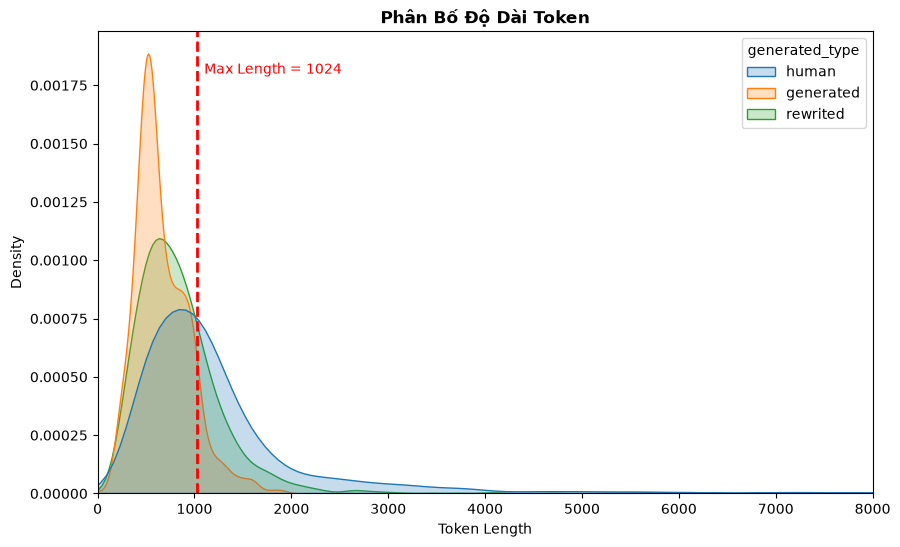

In [33]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=it_ai_human_df,
    x='token_length',
    hue='generated_type',
    fill=True,
    common_norm=False
)
plt.axvline(
    x=1024, 
    color='red',
    linestyle='--',
    linewidth=2,
)
plt.text(1100, 0.0018, 'Max Length = 1024', color='red')
plt.title('Phân Bố Độ Dài Token', fontweight='bold')
plt.xlabel('Token Length')
plt.xlim(0, 8000)
plt.ylabel('Density')
plt.savefig('../figures/preprocessing/token_length_kde_plot.png')
plt.show()

In [12]:
# Token length statistics
it_ai_human_df['token_length'].describe()

count     5000.000000
mean       994.393600
std        811.349829
min         10.000000
25%        558.000000
50%        820.000000
75%       1135.250000
max      12448.000000
Name: token_length, dtype: float64

In [34]:
MAX_LENGTH = 1024
# Real tokens
actual_tokens = it_ai_human_df['token_length'].clip(upper=MAX_LENGTH).sum()
# Padding tokens
padding_tokens = (MAX_LENGTH - it_ai_human_df['token_length'].clip(upper=MAX_LENGTH)).sum()

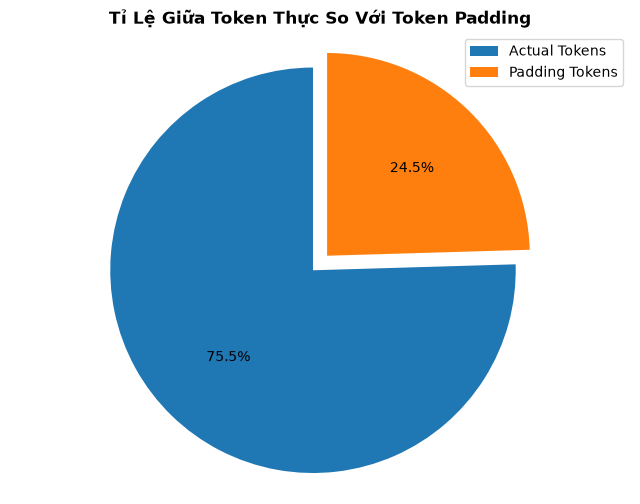

In [35]:
plt.figure(figsize=(8, 6))
plt.pie(
    [actual_tokens, padding_tokens],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.02, 0.08)
)
plt.title('Tỉ Lệ Giữa Token Thực So Với Token Padding', fontweight='bold')
plt.axis('equal')
plt.legend(['Actual Tokens', 'Padding Tokens'])
plt.savefig('../figures/preprocessing/actual_padding_tokens.png')
plt.show()

## **6. Save Data**

In [36]:
# Remaining cols for training
it_ai_human_df = it_ai_human_df[['cleaned_text', 'original_text', 'tokens', 'generated_type', 'label']] 

In [37]:
it_ai_human_df.to_csv('../data/preprocessing/it_ai_human_preprocessing_data.csv', index=False, encoding='utf-8-sig')